# Jupyter Notebook: High Frequency Words (Bible Corpus)


## MODULE 1 — Performance Tracking Utilities

This module initializes timing functions to track performance across the pipeline. This mirrors reproducible data engineering practices.

In [1]:
# ============================================
# MODULE 0: PERFORMANCE TRACKING UTILITIES
# ============================================

import time

PIPELINE_START = time.perf_counter()
TIMINGS = []

def start_timer():
    return time.perf_counter()

def end_timer(start, label):
    elapsed = time.perf_counter() - start
    TIMINGS.append((label, elapsed))
    print(f"[TIMER] {label}: {elapsed:.2f} seconds")

## MODULE 1 — Load Corpus

Load the Bible text as the corpus for analysis.

In [2]:
import pandas as pd
from collections import Counter
import requests

url = "https://raw.githubusercontent.com/professorfoy/data620/main/assignment-05-high-frequency-words/bible.txt"

response = requests.get(url)

text = response.text

print(text[:1000])  # preview first 1000 characters

THE
HOLY BIBLE
HOLMAN BIBLE PUBLISHERS 
NASHVILLE, TENNESSEE
CSB_Pew_Bible.indb   1
10/26/17   8:59 PM
CSB Pew Bible
Copyright © 2017 by Holman Bible Publishers
Nashville, Tennessee. All Rights Reserved.
Christian Standard Bible®
Copyright © 2017
by Holman Bible Publishers.
The text of the Christian Standard Bible may be quoted in any form (written, visual, 
electronic, or audio) up to and inclusive of one-thousand (1,000) verses without the 
written permission of the publisher, provided that the verses quoted do not account for 
more than 50 percent of the work in which they are quoted, and provided that a complete 
book of the Bible is not quoted. Requests for permission are to be directed to and approved 
in writing by Holman Bible Publishers, One LifeWay Plaza, Nashville, Tennessee 37234.
When the Christian Standard Bible is quoted, one of the following credit lines must 
appear on the copyright page or title page of the work:
Scripture quotations marked CSB hav


## MODULE 2 — Clean & Tokenize

Normalize text and convert into tokens.

In [3]:
# ============================================
# MODULE 2: CLEAN & TOKENIZE
# ============================================
import re
start = start_timer()

text = text.lower()
text = re.sub(r'[^a-z\s]', '', text)

words = text.split()

end_timer(start, "Tokenization")

print("Total words:", len(words))

[TIMER] Tokenization: 0.58 seconds
Total words: 796879


## MODULE 3 — Remove Stopwords

We remove common stopwords to isolate meaningful words. This allows comparison between structural vs semantic language.

In [4]:
# ============================================
# MODULE 3: REMOVE STOPWORDS
# ============================================

start = start_timer()

import nltk

try:
    from nltk.corpus import stopwords
    stopwords.words('english')
except LookupError:
    nltk.download('stopwords')

nltk.download('stopwords', quiet=True)

stop_words = set(stopwords.words('english'))

words_no_stop = [w for w in words if w not in stop_words]

end_timer(start, "Stopword Removal")

print("Words WITH stopwords:", len(words))
print("Words WITHOUT stopwords:", len(words_no_stop))

[TIMER] Stopword Removal: 3.74 seconds
Words WITH stopwords: 796879
Words WITHOUT stopwords: 374309


## MODULE 4 — Unique Words Comparison

Compare vocabulary size across both corpora.

In [5]:
# ============================================
# MODULE 4: UNIQUE WORDS COMPARISON
# ============================================

start = start_timer()

unique_with = len(set(words))
unique_without = len(set(words_no_stop))

end_timer(start, "Unique Words")

print("Unique WITH stopwords:", unique_with)
print("Unique WITHOUT stopwords:", unique_without)

[TIMER] Unique Words: 0.08 seconds
Unique WITH stopwords: 17869
Unique WITHOUT stopwords: 17733


## MODULE 5 — Frequency Analysis (Both)

Compute word frequencies for both corpora.

In [6]:
# ============================================
# MODULE 5: FREQUENCY ANALYSIS
# ============================================

start = start_timer()

df_with = pd.DataFrame(Counter(words).items(), columns=["word", "count"]).sort_values(by="count", ascending=False)

df_without = pd.DataFrame(Counter(words_no_stop).items(), columns=["word", "count"]).sort_values(by="count", ascending=False)

end_timer(start, "Frequency Analysis")

df_with.head(), df_without.head()

[TIMER] Frequency Analysis: 0.25 seconds


(    word  count
 0    the  57655
 33   and  29335
 19    of  25315
 32    to  21774
 509  you  14234,
      word  count
 610  lord   6960
 218   god   4375
 39    one   3310
 782  said   2881
 692   lit   2772)

## MODULE 6 — 50% Coverage Comparison

Determine how many words make up 50% of each corpus.

In [7]:
# ============================================
# MODULE 6: 50% COVERAGE COMPARISON
# ============================================

start = start_timer()

def coverage(df, total):
    df['cum'] = df['count'].cumsum()
    return (df['cum'] <= total*0.5).sum()

cov_with = coverage(df_with.copy(), len(words))
cov_without = coverage(df_without.copy(), len(words_no_stop))

end_timer(start, "Coverage")

print("WITH stopwords:", cov_with)
print("WITHOUT stopwords:", cov_without)

[TIMER] Coverage: 0.01 seconds
WITH stopwords: 55
WITHOUT stopwords: 362


## MODULE 7 — Top 200 Comparison

Compare the most frequent words across both corpora.

In [8]:
# ============================================
# MODULE 7: TOP 200 WORDS
# ============================================

start = start_timer()

top200_with = df_with.head(200).copy()
top200_without = df_without.head(200).copy()

end_timer(start, "Top 200 Extraction")

[TIMER] Top 200 Extraction: 0.00 seconds


## MODULE 8 — Relative Frequency Comparison

Visualize how stopwords impact distribution.

[TIMER] Relative Frequency Plot: 0.05 seconds


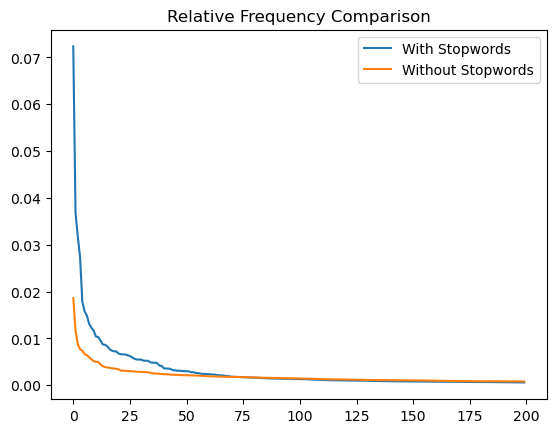

In [9]:
# ============================================
# MODULE 8: RELATIVE FREQUENCY COMPARISON
# ============================================
import matplotlib.pyplot as plt

start = start_timer()

top200_with['rel'] = top200_with['count'] / len(words)
top200_without['rel'] = top200_without['count'] / len(words_no_stop)

plt.figure()
plt.plot(top200_with['rel'].values, label="With Stopwords")
plt.plot(top200_without['rel'].values, label="Without Stopwords")
plt.legend()
plt.title("Relative Frequency Comparison")

end_timer(start, "Relative Frequency Plot")

## MODULE 9 — Zipf Comparison

Assess whether both follow Zipf’s law.

[TIMER] Zipf Plot: 0.03 seconds


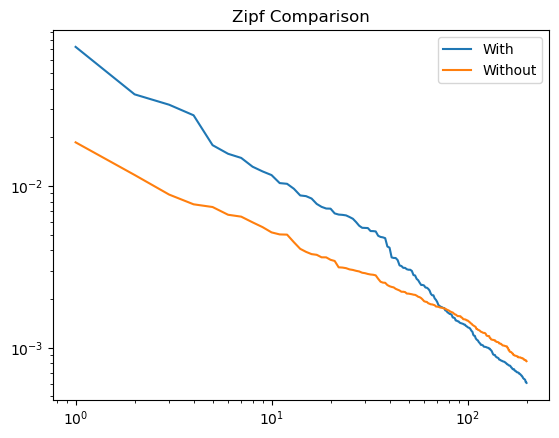

In [10]:
# ============================================
# MODULE 9: ZIPF COMPARISON
# ============================================
import numpy as np

start = start_timer()

ranks = np.arange(1, 201)

plt.figure()
plt.loglog(ranks, top200_with['rel'], label="With")
plt.loglog(ranks, top200_without['rel'], label="Without")
plt.legend()
plt.title("Zipf Comparison")

end_timer(start, "Zipf Plot")

## MODULE 10 — Interpretation

Your earlier findings show dominance of function words.
Removing stopwords shifts the analysis toward semantic meaning, revealing theological and narrative structure.

===========================================================================================

## MODULE 11 — Network (NO STOPWORDS)

In [11]:
# ============================================
# MODULE 11: NETWORK (NO STOPWORDS)
# ============================================

import networkx as nx
from itertools import combinations

start = start_timer()

G = nx.Graph()

for i in range(len(words_no_stop)-2):
    window = words_no_stop[i:i+2]
    for w1, w2 in combinations(window,2):
        G.add_edge(w1,w2)

end_timer(start, "Network Construction")

[TIMER] Network Construction: 1.73 seconds


## MODULE 12 — Centrality + Plot

In [12]:
# ============================================
# MODULE 12: CENTRALITY ANALYSIS
# ============================================

start = start_timer()

top_words = set(top200_without['word'])
G_sub = G.subgraph(top_words)

deg = nx.degree_centrality(G_sub)
bet = nx.betweenness_centrality(G_sub)
eig = nx.eigenvector_centrality(G_sub, max_iter=1000)

centrality_df = pd.DataFrame({
    "degree": deg,
    "betweenness": bet,
    "eigenvector": eig
}).sort_values(by="eigenvector", ascending=False)

end_timer(start, "Centrality")

centrality_df.head(10)

[TIMER] Centrality: 16.50 seconds


,degree,betweenness,eigenvector
lord,1.000000,0.007022,0.107942
one,0.974874,0.006453,0.105542
god,0.959799,0.006069,0.104772
people,0.944724,0.005418,0.103859
said,0.944724,0.005756,0.103187
lit,0.934673,0.005917,0.101639
b,0.934673,0.006958,0.101385
come,0.899497,0.004618,0.099996
c,0.924623,0.006951,0.099979
king,0.864322,0.004466,0.095877


## MODULE 13 — INFLUENCE BAR CHART

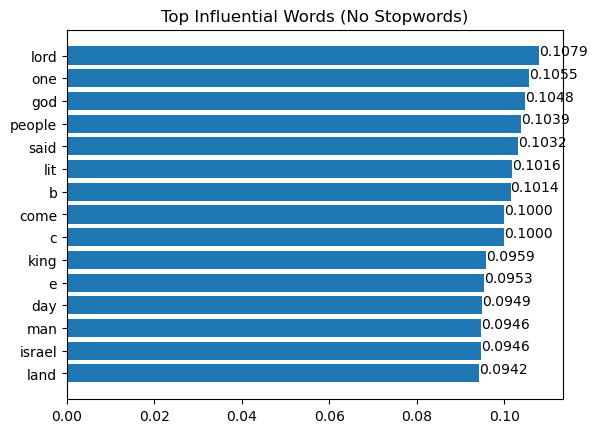

In [13]:
# ============================================
# MODULE 13: INFLUENCE BAR CHART
# ============================================

import textwrap

top = centrality_df.head(15)[::-1]

labels = [textwrap.fill(w,10) for w in top.index]

plt.figure()
plt.barh(labels, top['eigenvector'])
plt.title("Top Influential Words (No Stopwords)")

for i,v in enumerate(top['eigenvector']):
    plt.text(v,i,f"{v:.4f}")

plt.show()

## MODULE 14 — Degree Centrality

Measures how connected each word is in the network.

In [14]:
# ============================================
# MODULE 14: DEGREE CENTRALITY
# ============================================

start = start_timer()

degree_centrality = nx.degree_centrality(G_sub)

deg_df = pd.DataFrame.from_dict(degree_centrality, orient='index', columns=['degree'])
deg_df = deg_df.sort_values(by='degree', ascending=False)

end_timer(start, "Degree Centrality")

deg_df.head(10)

[TIMER] Degree Centrality: 0.08 seconds


,degree
lord,1.000000
one,0.974874
god,0.959799
people,0.944724
said,0.944724
lit,0.934673
b,0.934673
c,0.924623
come,0.899497
e,0.879397


## MODULE 15 — Betweenness Centrality

Identifies words that act as bridges across contexts.

In [15]:
# ============================================
# MODULE 15: BETWEENNESS CENTRALITY
# ============================================

start = start_timer()

betweenness = nx.betweenness_centrality(G_sub)

bet_df = pd.DataFrame.from_dict(betweenness, orient='index', columns=['betweenness'])
bet_df = bet_df.sort_values(by='betweenness', ascending=False)

end_timer(start, "Betweenness Centrality")

bet_df.head(10)

[TIMER] Betweenness Centrality: 16.74 seconds


,betweenness
lord,0.007022
b,0.006958
c,0.006951
one,0.006453
e,0.006276
god,0.006069
lit,0.005917
said,0.005756
people,0.005418
f,0.005174


## MODULE 16 — Eigenvector Centrality

Captures influence — words connected to other important words.

In [16]:
# ============================================
# MODULE 16: EIGENVECTOR CENTRALITY
# ============================================

start = start_timer()

eigen = nx.eigenvector_centrality(G_sub, max_iter=1000)

eig_df = pd.DataFrame.from_dict(eigen, orient='index', columns=['eigenvector'])
eig_df = eig_df.sort_values(by='eigenvector', ascending=False)

end_timer(start, "Eigenvector Centrality")

eig_df.head(10)

[TIMER] Eigenvector Centrality: 0.51 seconds


,eigenvector
lord,0.107942
one,0.105542
god,0.104772
people,0.103859
said,0.103187
lit,0.101639
b,0.101385
come,0.099996
c,0.099979
king,0.095877


## MODULE 17 — Combine Metrics

Combines all centrality measures into a single analytical table.

In [17]:
# ============================================
# MODULE 17: COMBINE CENTRALITY METRICS
# ============================================

centrality_df = deg_df.join(bet_df).join(eig_df)

centrality_df.sort_values(by='eigenvector', ascending=False).head(10)

,degree,betweenness,eigenvector
lord,1.000000,0.007022,0.107942
one,0.974874,0.006453,0.105542
god,0.959799,0.006069,0.104772
people,0.944724,0.005418,0.103859
said,0.944724,0.005756,0.103187
lit,0.934673,0.005917,0.101639
b,0.934673,0.006958,0.101385
come,0.899497,0.004618,0.099996
c,0.924623,0.006951,0.099979
king,0.864322,0.004466,0.095877


## MODULE 18 — Network Visualization

Visual representation of word relationships.

[TIMER] Network Plot: 1.32 seconds


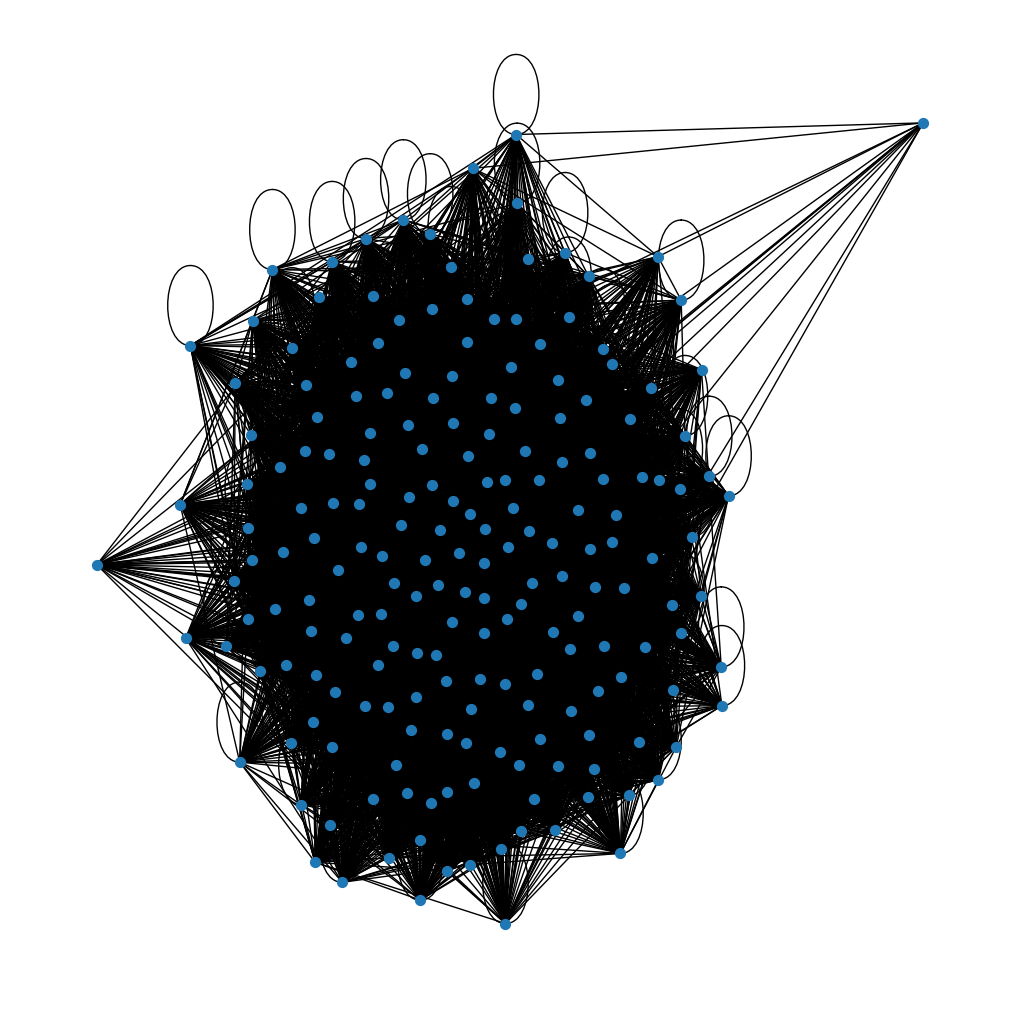

In [18]:
# ============================================
# MODULE 18: NETWORK VISUALIZATION
# ============================================

start = start_timer()

plt.figure(figsize=(10,10))

pos = nx.spring_layout(G_sub, k=0.3)

nx.draw(G_sub, pos, node_size=50, with_labels=False)

end_timer(start, "Network Plot")

plt.show()

## MODULE 19 — Top Influential Words

Identify most influential words using eigenvector centrality.

In [19]:
# ============================================
# MODULE 19: TOP INFLUENTIAL WORDS
# ============================================

start = start_timer()

top_influential = (
    centrality_df
    .sort_values(by='eigenvector', ascending=False)
    .head(15)
)

end_timer(start, "Top Influential Words")

top_influential

[TIMER] Top Influential Words: 0.00 seconds


,degree,betweenness,eigenvector
lord,1.000000,0.007022,0.107942
one,0.974874,0.006453,0.105542
god,0.959799,0.006069,0.104772
people,0.944724,0.005418,0.103859
said,0.944724,0.005756,0.103187
lit,0.934673,0.005917,0.101639
b,0.934673,0.006958,0.101385
come,0.899497,0.004618,0.099996
c,0.924623,0.006951,0.099979
king,0.864322,0.004466,0.095877


## MODULE 20 — Publication Bar Chart

Professional visualization of influential words.

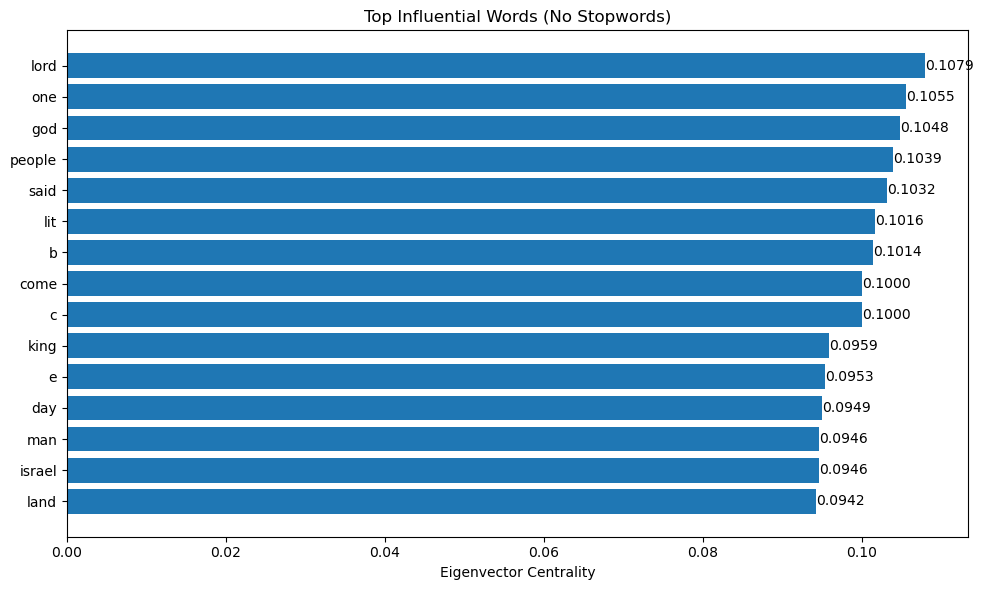

[TIMER] Bar Chart: 0.63 seconds


In [20]:
# ============================================
# MODULE 20: BAR CHART
# ============================================

import textwrap

start = start_timer()

plot_df = top_influential[::-1]

labels = [textwrap.fill(word, 10) for word in plot_df.index]

plt.figure(figsize=(10,6))
plt.barh(labels, plot_df['eigenvector'])

for i, v in enumerate(plot_df['eigenvector']):
    plt.text(v, i, f"{v:.4f}", va='center')

plt.title("Top Influential Words (No Stopwords)")
plt.xlabel("Eigenvector Centrality")

plt.tight_layout()
plt.show()

end_timer(start, "Bar Chart")

## MODULE 21 — Centrality Comparison Table

In [21]:
# ============================================
# MODULE 21: COMPARISON TABLE
# ============================================

comparison = centrality_df.sort_values(by='eigenvector', ascending=False).head(15)

comparison

,degree,betweenness,eigenvector
lord,1.000000,0.007022,0.107942
one,0.974874,0.006453,0.105542
god,0.959799,0.006069,0.104772
people,0.944724,0.005418,0.103859
said,0.944724,0.005756,0.103187
lit,0.934673,0.005917,0.101639
b,0.934673,0.006958,0.101385
come,0.899497,0.004618,0.099996
c,0.924623,0.006951,0.099979
king,0.864322,0.004466,0.095877


## MODULE 22 — Multi-Metric Plot



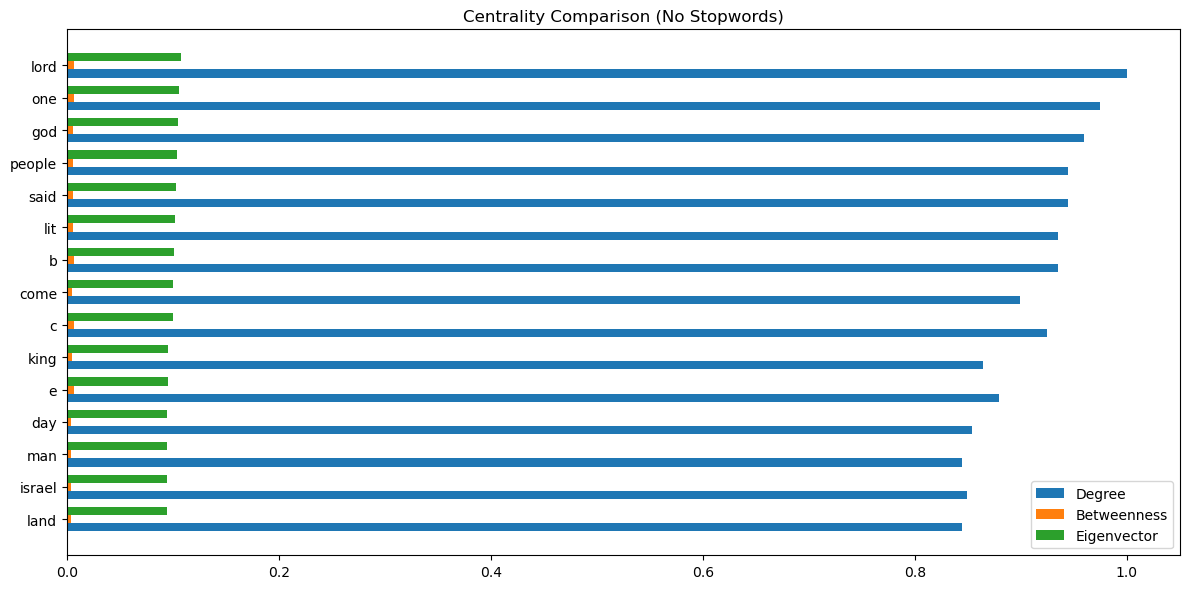

[TIMER] Multi-Metric Plot: 0.52 seconds


In [22]:
# ============================================
# MODULE 22: MULTI-METRIC PLOT
# ============================================

start = start_timer()

plot_df = comparison[::-1]

labels = [textwrap.fill(word, 10) for word in plot_df.index]

x = np.arange(len(labels))

plt.figure(figsize=(12,6))

plt.barh(x - 0.25, plot_df['degree'], height=0.25, label='Degree')
plt.barh(x, plot_df['betweenness'], height=0.25, label='Betweenness')
plt.barh(x + 0.25, plot_df['eigenvector'], height=0.25, label='Eigenvector')

plt.yticks(x, labels)

plt.legend()
plt.title("Centrality Comparison (No Stopwords)")

plt.tight_layout()
plt.show()

end_timer(start, "Multi-Metric Plot")

## SECTION # — Interpretation

Zipf’s Law:
The plot shows that word frequency decreases roughly inversely with rank. This suggests the Bible corpus approximately follows Zipf’s Law, where:

𝑓
𝑟
𝑒
𝑞
𝑢
𝑒
𝑛
𝑐
𝑦
∝
1
𝑟
𝑎
𝑛
𝑘
frequency∝
rank
1
	​


Observations:

High-frequency words include function words like the, and, of, to
A small number of words dominate the corpus
Long-tail distribution exists (many rare words)